## Model Training V3

This uses the best max token length and hyperparameters to train the model to obtain the best performance.

This version includes experimentation with feature selection to reduce noise for the most optimal signal extraction.

Loads the existing FastText embeddings and preprocessed data, then trains the model with improvements to boost fake-class recall.

### Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from gensim.models import FastText
from nltk.tokenize import word_tokenize
from torch.utils.data import DataLoader
from dataset_class.job_post_dataset import JobPostingDataset
from model_construction.model import FakeJobDetector
import os, json, pickle
import math


#Load preprocessed data
combined_df = pd.read_csv("./data/clean/fake_job_postings_ALL.csv")

# Commenting out some of the features to reduce dimensionality and focus on the most relevant ones for the model. 
# We can always add them back later if needed.

numeric_cols = [
    "telecommuting", "missing_count", "total_text_len", 
    # "company_profile_len", "description_len", "requirements_len", "benefits_len",
    "company_profile_word_count", "description_word_count", "requirements_word_count", 
    # "benefits_word_count",
    "salary_provided", "has_company_profile", "vague_location",
    "has_company_logo", "has_questions"
]

print(f"Dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} cols")
print(f"Class balance: {combined_df['fraudulent'].value_counts().to_dict()}")

C:\Users\HP Victus\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Dataset: 17880 rows, 18 cols
Class balance: {0: 17014, 1: 866}


### Train - Test - Validation Split

In [2]:
#Train / Val / Test split (80/10/10, stratified so same proportion of fraudulent vs non-fraudulent in each set)
train_data, temp_data = train_test_split(
    combined_df, test_size=0.2, random_state=42, stratify=combined_df['fraudulent']
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['fraudulent']
)

X_train_text    = train_data['full_text'].tolist()
X_train_numeric = train_data[numeric_cols].values.astype(np.float32)
y_train         = train_data['fraudulent'].values.tolist()

X_val_text      = val_data['full_text'].tolist()
X_val_numeric   = val_data[numeric_cols].values.astype(np.float32)
y_val           = val_data['fraudulent'].values.tolist()

X_test_text     = test_data['full_text'].tolist()
X_test_numeric  = test_data[numeric_cols].values.astype(np.float32)
y_test          = test_data['fraudulent'].values.tolist()

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Train: 14304, Val: 1788, Test: 1788


### Non-Binary Value Standardisation

In [3]:
# Scale non-binary numeric features

# Commenting out some of the features to reduce dimensionality and focus on the most relevant ones for the model.

non_binary_cols = [
    "missing_count", "total_text_len", 
    # "company_profile_len", "description_len", "requirements_len", "benefits_len", 
    "company_profile_word_count", "description_word_count", "requirements_word_count", 
    # "benefits_word_count"
]
non_binary_indices = [numeric_cols.index(col) for col in non_binary_cols]

scaler = StandardScaler()
X_train_numeric[:, non_binary_indices] = scaler.fit_transform(X_train_numeric[:, non_binary_indices])
X_val_numeric[:,   non_binary_indices] = scaler.transform(X_val_numeric[:,   non_binary_indices])
X_test_numeric[:,  non_binary_indices] = scaler.transform(X_test_numeric[:,  non_binary_indices])

### Loading Fine-tuned FastText model

In [4]:
#Load pretrained FastText embeddings
fasttext_model = FastText.load("./optimal_fasttext.bin")
print(f"FastText vocab: {len(fasttext_model.wv)} words, {fasttext_model.wv.vector_size}-dim")

FastText vocab: 22094 words, 100-dim


### Tokenizing and encoding tokens into numerical values

These tokens and numerical representations are cached thereafter so as to save time from tokenizing and encoding all of the datasets.

In [5]:
CACHE_DIR = "./data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

tok_cache   = os.path.join(CACHE_DIR, "tokenized_splits.pkl")
vocab_cache = os.path.join(CACHE_DIR, "vocab.json")

if os.path.exists(tok_cache) and os.path.exists(vocab_cache):
    #Load cached tokenized data
    print("Loading cached tokenized data...")
    with open(tok_cache, "rb") as f:
        cached = pickle.load(f)
    train_texts_tok = cached["train"]
    val_texts_tok   = cached["val"]
    test_texts_tok  = cached["test"]

    with open(vocab_cache, "r") as f:
        vocab = json.load(f)

    print(f"Vocab size: {len(vocab)} (loaded from cache)")
else:
    #Tokenize and encode from scratch
    print("Tokenizing (first run, will be cached)...")
    train_tk = [word_tokenize(text.lower()) for text in X_train_text]
    val_tk   = [word_tokenize(text.lower()) for text in X_val_text]
    test_tk  = [word_tokenize(text.lower()) for text in X_test_text]

    # Build vocab from FastText (0=<unk>, 1=<pad>, 2+=words)
    vocab = {"<unk>": 0, "<pad>": 1}
    for idx, word in enumerate(fasttext_model.wv.index_to_key):
        vocab[word] = idx + 2

    def encode(tokens, vocab):
        return [vocab.get(t, 0) for t in tokens]

    train_texts_tok = [encode(s, vocab) for s in train_tk]
    val_texts_tok   = [encode(s, vocab) for s in val_tk]
    test_texts_tok  = [encode(s, vocab) for s in test_tk]

    # Save cache
    with open(tok_cache, "wb") as f:
        pickle.dump({"train": train_texts_tok, "val": val_texts_tok, "test": test_texts_tok}, f)
    with open(vocab_cache, "w") as f:
        json.dump(vocab, f)

    print(f"Vocab size: {len(vocab)} (saved to cache)")

Loading cached tokenized data...
Vocab size: 22096 (loaded from cache)


### Instantiating Datasets and DataLoaders

In [6]:
#Create Datasets and DataLoader
MAX_LEN    = 2048
BATCH_SIZE = 64
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_dataset = JobPostingDataset(train_texts_tok, X_train_numeric, y_train, max_len=MAX_LEN)
val_dataset   = JobPostingDataset(val_texts_tok,   X_val_numeric,   y_val,   max_len=MAX_LEN)
test_dataset  = JobPostingDataset(test_texts_tok,  X_test_numeric,  y_test,  max_len=MAX_LEN)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dataloader)}, Val: {len(val_dataloader)}, Test: {len(test_dataloader)}")

Train batches: 224, Val: 28, Test: 28


### Creating Embedding Matrix

This is to be copied into the embedding layer of the architecture.

In [7]:
#Build embedding matrix from FastText
vocab_size = len(vocab)
embed_dim  = fasttext_model.wv.vector_size

embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
for word, idx in vocab.items():
    if word in fasttext_model.wv:
        embedding_matrix[idx] = fasttext_model.wv[word]

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float)
print(f"Embedding matrix: {pretrained_embeddings.shape}")

Embedding matrix: torch.Size([22096, 100])


### Instantiate Model

In [8]:
#Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FakeJobDetector(
    vocab_size             = vocab_size,
    embed_dim              = embed_dim,
    gru_hidden_dim         = 64,
    num_numerical_features = X_train_numeric.shape[1],
    num_hidden_dim         = 64,
    pretrained_embeddings  = pretrained_embeddings,
    device                 = device,
)
print(f"Device: {device}")
print(model)
print("cuda available:", torch.cuda.is_available())

num_real = sum(1 for y in y_train if y == 0)
num_fake = sum(1 for y in y_train if y == 1)
print(f"Num real: {num_real}, Num fake: {num_fake}")

Device: cuda
FakeJobDetector(
  (embedding): Embedding(22096, 100, padding_idx=1)
  (bigru): BiGRUBlock(
    (gru): GRU(100, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  )
  (attention): MultiHeadAttentionPooling(
    (heads): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=1, bias=True)
    )
    (projection): Linear(in_features=256, out_features=128, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (numerical): NumericalBlock(
    (layers): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Linear(in_features=192, out_features=1, bias=True)
)
cuda available: True
Num real: 13611, Num fake: 693


### Model Training

In [9]:
#Train
num_real = sum(1 for y in y_train if y == 0)
num_fake = sum(1 for y in y_train if y == 1)

train_losses, val_losses, train_accuracy, val_accuracy = model.fit(
    dataloader     = train_dataloader,
    val_dataloader = val_dataloader,
    num_epochs     = 20,
    learning_rate  = 1e-3,
    save_path      = "best_model_v8.pt",
)


Epoch 1/20 | Train Loss: 0.0468 | Val Loss: 0.0419
  ✅ Best model saved (val_loss=0.0419)
Epoch 2/20 | Train Loss: 0.0377 | Val Loss: 0.0409
  ✅ Best model saved (val_loss=0.0409)
Epoch 3/20 | Train Loss: 0.0328 | Val Loss: 0.0257
  ✅ Best model saved (val_loss=0.0257)
Epoch 4/20 | Train Loss: 0.0257 | Val Loss: 0.0207
  ✅ Best model saved (val_loss=0.0207)
Epoch 5/20 | Train Loss: 0.0218 | Val Loss: 0.0172
  ✅ Best model saved (val_loss=0.0172)
Epoch 6/20 | Train Loss: 0.0210 | Val Loss: 0.0166
  ✅ Best model saved (val_loss=0.0166)
Epoch 7/20 | Train Loss: 0.0186 | Val Loss: 0.0163
  ✅ Best model saved (val_loss=0.0163)
Epoch 8/20 | Train Loss: 0.0167 | Val Loss: 0.0157
  ✅ Best model saved (val_loss=0.0157)
Epoch 9/20 | Train Loss: 0.0170 | Val Loss: 0.0197
  ⚠️ No improvement (best_val_loss=0.0157)
Epoch 10/20 | Train Loss: 0.0169 | Val Loss: 0.0196
  ⚠️ No improvement (best_val_loss=0.0157)
Epoch 11/20 | Train Loss: 0.0150 | Val Loss: 0.0197
  ⚠️ No improvement (best_val_loss=0.01

### Hyperparameter Threshold Tuning

In [10]:
#Evaluate on test set
for threshold in [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8]:
    print(f"\n--- Threshold: {threshold} ---")
    model.evaluate(test_dataloader, threshold=threshold)


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

        Real       1.00      0.96      0.98      1702
        Fake       0.57      0.94      0.71        86

    accuracy                           0.96      1788
   macro avg       0.78      0.95      0.84      1788
weighted avg       0.98      0.96      0.97      1788


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99      1702
        Fake       0.75      0.90      0.81        86

    accuracy                           0.98      1788
   macro avg       0.87      0.94      0.90      1788
weighted avg       0.98      0.98      0.98      1788


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      1702
        Fake       0.80      0.90      0.85        86

    accuracy                           0.98      1788
   macro avg       0.90      0.94      0.92      1788
we

### Loss and Accuracy Visualisation

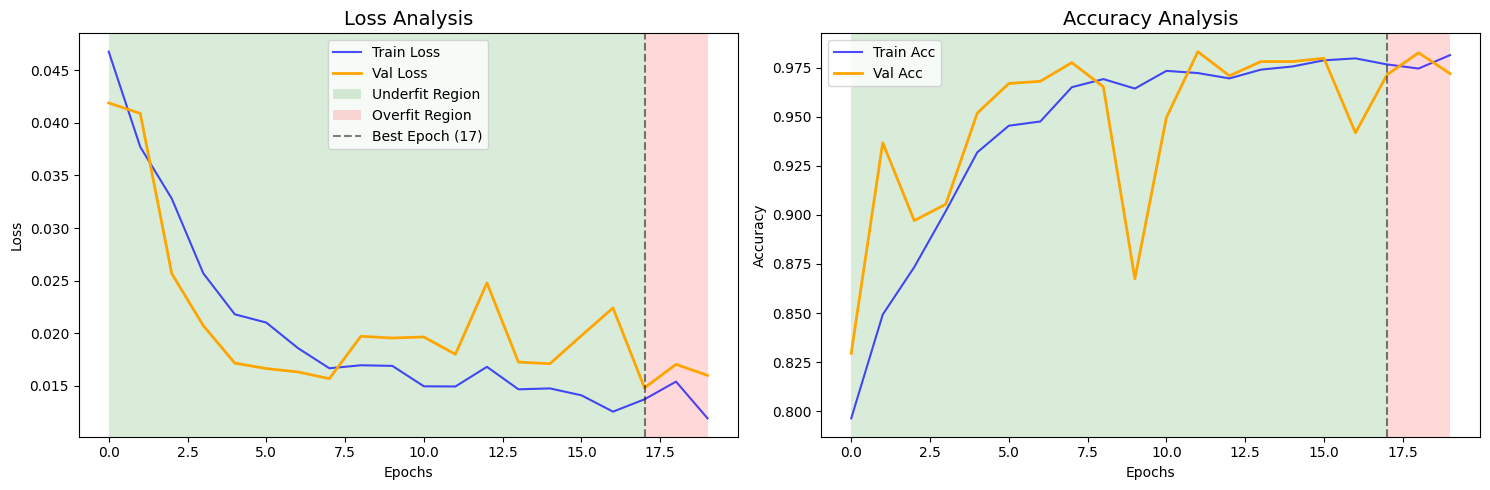

In [11]:
import matplotlib.pyplot as plt

# Find the index of the lowest validation loss
best_epoch = val_losses.index(min(val_losses))
total_epochs = len(val_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# loss plot
ax1.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
ax1.plot(val_losses, label='Val Loss', color='orange', linewidth=2)

# Dynamic spans based on best_epoch
ax1.axvspan(0, best_epoch, facecolor='green', alpha=0.15, label="Underfit Region")
ax1.axvspan(best_epoch, total_epochs - 1, facecolor='red', alpha=0.15, label="Overfit Region")

# Add a vertical line at the "sweet spot"
ax1.axvline(best_epoch, color='black', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')

ax1.set_title('Loss Analysis', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(train_accuracy, label='Train Acc', color='blue', alpha=0.7)
ax2.plot(val_accuracy, label='Val Acc', color='orange', linewidth=2)

# show the zones on the accuracy plot as well for consistency
ax2.axvspan(0, best_epoch, facecolor='green', alpha=0.15)
ax2.axvspan(best_epoch, total_epochs - 1, facecolor='red', alpha=0.15)
ax2.axvline(best_epoch, color='black', linestyle='--', alpha=0.5)

ax2.set_title('Accuracy Analysis', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()


### Confusion Matrix Report Visualisation

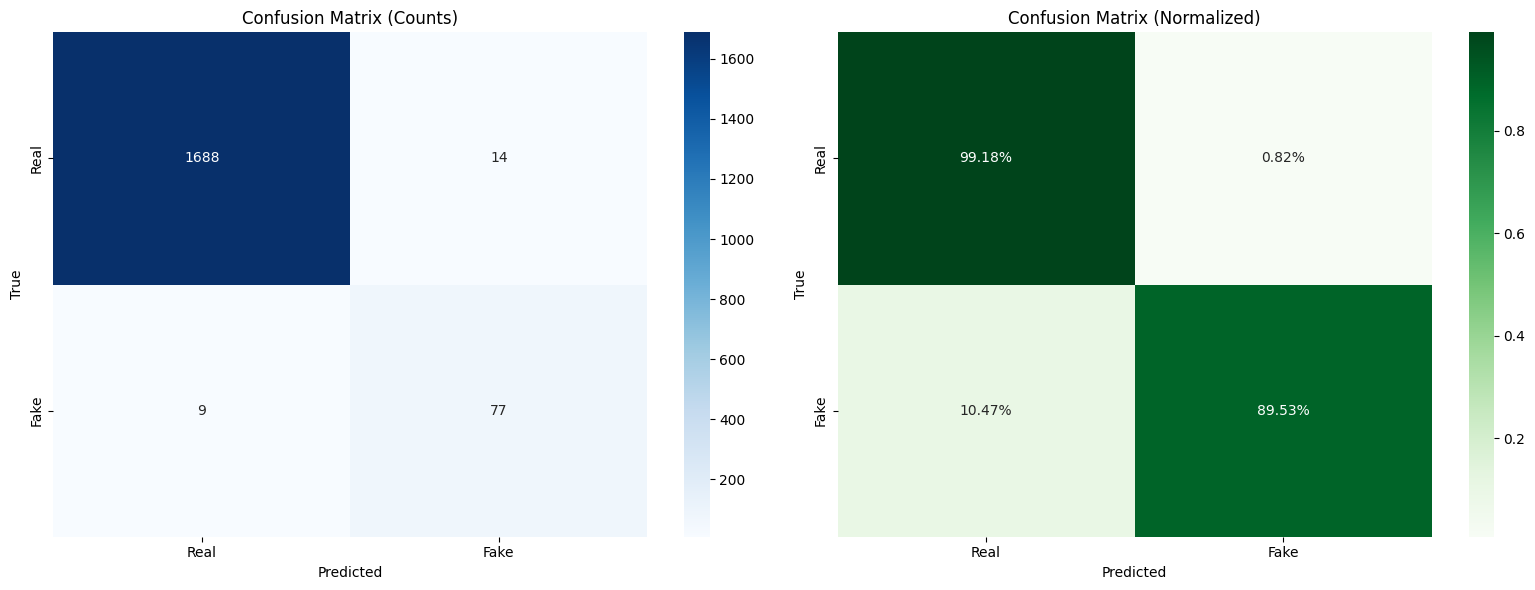

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def plot_confusion_matrix(model, iterator, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in iterator:
            # Move all inputs to device
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            numerical_features = inputs['numerical_features'].to(device)
            targets = targets.to(device).float()

            outputs = model(input_ids, attention_mask, numerical_features).squeeze()
            preds = torch.round(torch.sigmoid(outputs)) 
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    # Compute Matrices
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize by the number of true labels (rows)
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    labels = ['Real', 'Fake']

    # --- Raw Counts ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=labels, yticklabels=labels)
    ax1.set_title('Confusion Matrix (Counts)')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # --- Normalized ---
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax2,
                xticklabels=labels, yticklabels=labels)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.show()
        



plot_confusion_matrix(model, test_dataloader, device)